[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YangKCLab/social-media-analysis/blob/main/docs/topics/network/centrality-and-communities.ipynb)

# Centrality and communities

A centrality measure gives each node of a network a number for its importance.
A community is a group of nodes with many edges inside the group and fewer edges to the rest of the network.
This notebook computes five centrality measures on the character networks of two books.
It then finds communities with the Louvain method, first in Zachary's karate club network and then in the character network of the first book.

Sections: Load the character network, Compute the centrality measures, The most central characters, Book 1 and book 2, Load the karate club network, Communities with the Louvain method, Draw the communities, Communities of the character network.

Packages beyond the standard library: `networkx`, `pandas`, `matplotlib`, `scipy`.
Install them with `uv add networkx pandas matplotlib scipy` (or `pip install`).
Colab already has all four.
The notebook does not import `scipy`, but `nx.pagerank` and `nx.eigenvector_centrality_numpy` need it.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

## Load the character network

The data are character interaction networks of the book series "A Song of Ice and Fire", made
by Andrew Beveridge: [mathbeveridge/asoiaf](https://github.com/mathbeveridge/asoiaf). Two
characters are connected when their names appear within 15 words of each other in a book. The
data have the license [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).

In [2]:
import pathlib
import urllib.request

import networkx as nx
import pandas as pd

# The files are not in the site repository. This cell downloads them once from
# the repository of the data, at a fixed commit.
url = (
    "https://raw.githubusercontent.com/mathbeveridge/asoiaf/"
    "4003f7928ee65da712e9db44b3df860375d958e5/data/"
)
data_dir = pathlib.Path("data")
data_dir.mkdir(exist_ok=True)
for name in ["asoiaf-book1-edges.csv", "asoiaf-book2-edges.csv"]:
    if not (data_dir / name).exists():
        urllib.request.urlretrieve(url + name, data_dir / name)

got_book_1_edges = pd.read_csv(data_dir / "asoiaf-book1-edges.csv")
got_book_2_edges = pd.read_csv(data_dir / "asoiaf-book2-edges.csv")
len(got_book_1_edges)    # 684
len(got_book_2_edges)    # 775

775

The cell downloads the two files (28 KB and 32 KB) into `data/` next to this notebook, unless the files are already there.
The edge list of book 1 has 684 rows, and the edge list of book 2 has 775 rows.
A notebook shows only the value of the last line of a cell, which is 775 here.

In [3]:
got_book_1_edges.head(3)

,Source,Target,Type,weight,book
0,Addam-Marbrand,Jaime-Lannister,Undirected,3,1
1,Addam-Marbrand,Tywin-Lannister,Undirected,6,1
2,Aegon-I-Targaryen,Daenerys-Targaryen,Undirected,5,1


Each row is one edge.
The first three rows of book 1:

| Source | Target | Type | weight | book |
| --- | --- | --- | --- | --- |
| Addam-Marbrand | Jaime-Lannister | Undirected | 3 | 1 |
| Addam-Marbrand | Tywin-Lannister | Undirected | 6 | 1 |
| Aegon-I-Targaryen | Daenerys-Targaryen | Undirected | 5 | 1 |

`Source` and `Target` are the names of two characters.
`weight` is the number of times that the two names appear close to each other.

`nx.from_pandas_edgelist` builds a network from an edge list in a table.
The arguments `source` and `target` name the two columns that hold the nodes.

In [4]:
G_1 = nx.from_pandas_edgelist(
    got_book_1_edges, source="Source", target="Target", create_using=nx.Graph()
)
G_2 = nx.from_pandas_edgelist(
    got_book_2_edges, source="Source", target="Target", create_using=nx.Graph()
)

print(G_1.number_of_nodes(), G_1.number_of_edges())
print(G_2.number_of_nodes(), G_2.number_of_edges())

187 684
259 775


The network of book 1 has 187 nodes and 684 edges.
The network of book 2 has 259 nodes and 775 edges.

This code ignores the column `weight`, so every edge counts the same.

## Compute the centrality measures

Importance can mean different things, so there are many centrality measures.
NetworkX has one function for each measure.

| Measure | What it measures | Function |
| --- | --- | --- |
| Degree centrality | The number of edges of a node, divided by the number of other nodes | `nx.degree_centrality` |
| Betweenness | How often a node is on the shortest path between two other nodes | `nx.betweenness_centrality` |
| Closeness | The inverse of the average distance from a node to all other nodes | `nx.closeness_centrality` |
| PageRank | A node is important if important nodes link to it. `nx.pagerank` uses a damping factor of 0.85 by default | `nx.pagerank` |
| Eigenvector centrality | A node has a high value if its neighbors have high values | `nx.eigenvector_centrality_numpy` |

Each function returns a dictionary from node to value.
The function below puts the five dictionaries in one table, with one row for each node.

In [5]:
def centrality_table(G):
    return pd.DataFrame(
        {
            "degree_centrality": nx.degree_centrality(G),
            "betweenness": nx.betweenness_centrality(G, normalized=True),
            "closeness": nx.closeness_centrality(G),
            "pagerank": nx.pagerank(G),
            "eigenvector": nx.eigenvector_centrality_numpy(G),
        }
    )


centrality_df_1 = centrality_table(G_1)
centrality_df_2 = centrality_table(G_2)

Degree centrality in NetworkX is the degree divided by the number of other nodes.
The next cell checks this for one character.

In [6]:
print(G_1.degree("Eddard-Stark"))
print(G_1.degree("Eddard-Stark") / (G_1.number_of_nodes() - 1))
print(centrality_df_1.loc["Eddard-Stark", "degree_centrality"])

66
0.3548387096774194
0.3548387096774194


Eddard Stark has 66 edges, and book 1 has 186 other characters.
66 / 186 = 0.355, which is the value in the table.

## The most central characters

Sort the table by one measure to find the most central characters.
`kind="stable"` keeps two characters with the same value in the order of the table, so each run gives the same order.
`head(10)` keeps the first ten rows, and `round(3)` rounds the values to three decimals.

In [7]:
ranked = centrality_df_1.sort_values("degree_centrality", ascending=False, kind="stable")
ranked.head(10).round(3)

,degree_centrality,betweenness,closeness,pagerank,eigenvector
Eddard-Stark,0.355,0.270,0.564,0.046,0.296
Robert-Baratheon,0.269,0.214,0.545,0.030,0.269
Tyrion-Lannister,0.247,0.190,0.511,0.033,0.225
Catelyn-Stark,0.231,0.151,0.505,0.030,0.213
Jon-Snow,0.199,0.172,0.493,0.027,0.170
Robb-Stark,0.188,0.073,0.497,0.022,0.193
Sansa-Stark,0.188,0.037,0.489,0.020,0.232
Bran-Stark,0.172,0.056,0.487,0.020,0.194
Cersei-Lannister,0.161,0.026,0.484,0.017,0.216
Joffrey-Baratheon,0.161,0.019,0.481,0.017,0.221


The cell returns the ten characters with the highest degree centrality in book 1.
The first five rows:

| | degree_centrality | betweenness | closeness | pagerank | eigenvector |
| --- | --- | --- | --- | --- | --- |
| Eddard-Stark | 0.355 | 0.270 | 0.564 | 0.046 | 0.296 |
| Robert-Baratheon | 0.269 | 0.214 | 0.545 | 0.030 | 0.269 |
| Tyrion-Lannister | 0.247 | 0.190 | 0.511 | 0.033 | 0.225 |
| Catelyn-Stark | 0.231 | 0.151 | 0.505 | 0.030 | 0.213 |
| Jon-Snow | 0.199 | 0.172 | 0.493 | 0.027 | 0.170 |

The ranking depends on the measure.
The next two cells sort the table by PageRank and by betweenness.

In [8]:
ranked = centrality_df_1.sort_values("pagerank", ascending=False, kind="stable")
ranked.head(10).round(3)

,degree_centrality,betweenness,closeness,pagerank,eigenvector
Eddard-Stark,0.355,0.270,0.564,0.046,0.296
Tyrion-Lannister,0.247,0.190,0.511,0.033,0.225
Catelyn-Stark,0.231,0.151,0.505,0.030,0.213
Robert-Baratheon,0.269,0.214,0.545,0.030,0.269
Jon-Snow,0.199,0.172,0.493,0.027,0.170
Robb-Stark,0.188,0.073,0.497,0.022,0.193
Sansa-Stark,0.188,0.037,0.489,0.020,0.232
Bran-Stark,0.172,0.056,0.487,0.020,0.194
Jaime-Lannister,0.156,0.032,0.462,0.018,0.195
Cersei-Lannister,0.161,0.026,0.484,0.017,0.216


In [9]:
ranked = centrality_df_1.sort_values("betweenness", ascending=False, kind="stable")
ranked.head(10).round(3)

,degree_centrality,betweenness,closeness,pagerank,eigenvector
Eddard-Stark,0.355,0.270,0.564,0.046,0.296
Robert-Baratheon,0.269,0.214,0.545,0.030,0.269
Tyrion-Lannister,0.247,0.190,0.511,0.033,0.225
Jon-Snow,0.199,0.172,0.493,0.027,0.170
Catelyn-Stark,0.231,0.151,0.505,0.030,0.213
Daenerys-Targaryen,0.113,0.086,0.405,0.015,0.047
Robb-Stark,0.188,0.073,0.497,0.022,0.193
Drogo,0.102,0.065,0.380,0.015,0.023
Bran-Stark,0.172,0.056,0.487,0.020,0.194
Sansa-Stark,0.188,0.037,0.489,0.020,0.232


To compare the rankings, put the names side by side.
The function below returns the names of the ten nodes with the highest values of one measure.

In [10]:
def top_names(table, column, n=10):
    top = table.sort_values(column, ascending=False, kind="stable").head(n)
    return top.index.tolist()


pd.DataFrame(
    {
        "degree_centrality": top_names(centrality_df_1, "degree_centrality"),
        "pagerank": top_names(centrality_df_1, "pagerank"),
        "betweenness": top_names(centrality_df_1, "betweenness"),
    },
    index=range(1, 11),
)

,degree_centrality,pagerank,betweenness
1,Eddard-Stark,Eddard-Stark,Eddard-Stark
2,Robert-Baratheon,Tyrion-Lannister,Robert-Baratheon
3,Tyrion-Lannister,Catelyn-Stark,Tyrion-Lannister
4,Catelyn-Stark,Robert-Baratheon,Jon-Snow
5,Jon-Snow,Jon-Snow,Catelyn-Stark
6,Robb-Stark,Robb-Stark,Daenerys-Targaryen
7,Sansa-Stark,Sansa-Stark,Robb-Stark
8,Bran-Stark,Bran-Stark,Drogo
9,Cersei-Lannister,Jaime-Lannister,Bran-Stark
10,Joffrey-Baratheon,Cersei-Lannister,Sansa-Stark


The table has one row for each rank.
The first five rows:

| | degree_centrality | pagerank | betweenness |
| --- | --- | --- | --- |
| 1 | Eddard-Stark | Eddard-Stark | Eddard-Stark |
| 2 | Robert-Baratheon | Tyrion-Lannister | Robert-Baratheon |
| 3 | Tyrion-Lannister | Catelyn-Stark | Tyrion-Lannister |
| 4 | Catelyn-Stark | Robert-Baratheon | Jon-Snow |
| 5 | Jon-Snow | Jon-Snow | Catelyn-Stark |

Eddard Stark is first with all three measures.
Daenerys Targaryen (rank 6) and Drogo (rank 8) are in the top ten only by betweenness.
They have few links, but they connect their own group to the rest of the network.

## Book 1 and book 2

The network of book 2 has other characters and other edges, so the centrality of a character changes.

In [11]:
ranked = centrality_df_2.sort_values("degree_centrality", ascending=False, kind="stable")
ranked.head(10).round(3)

,degree_centrality,betweenness,closeness,pagerank,eigenvector
Tyrion-Lannister,0.205,0.155,0.444,0.028,0.283
Joffrey-Baratheon,0.182,0.091,0.439,0.022,0.307
Cersei-Lannister,0.167,0.064,0.431,0.020,0.295
Arya-Stark,0.155,0.188,0.435,0.022,0.193
Stannis-Baratheon,0.143,0.120,0.415,0.020,0.206
Robb-Stark,0.136,0.165,0.478,0.020,0.210
Catelyn-Stark,0.128,0.111,0.434,0.018,0.191
Theon-Greyjoy,0.124,0.144,0.371,0.023,0.071
Renly-Baratheon,0.120,0.072,0.410,0.017,0.191
Bran-Stark,0.116,0.113,0.414,0.018,0.091


Tyrion Lannister has the highest degree centrality in book 2, 0.205.
The next cell puts the top ten of the two books side by side.

In [12]:
pd.DataFrame(
    {
        "book_1": top_names(centrality_df_1, "degree_centrality"),
        "book_2": top_names(centrality_df_2, "degree_centrality"),
    },
    index=range(1, 11),
)

,book_1,book_2
1,Eddard-Stark,Tyrion-Lannister
2,Robert-Baratheon,Joffrey-Baratheon
3,Tyrion-Lannister,Cersei-Lannister
4,Catelyn-Stark,Arya-Stark
5,Jon-Snow,Stannis-Baratheon
6,Robb-Stark,Robb-Stark
7,Sansa-Stark,Catelyn-Stark
8,Bran-Stark,Theon-Greyjoy
9,Cersei-Lannister,Renly-Baratheon
10,Joffrey-Baratheon,Bran-Stark


The first five rows:

| | book_1 | book_2 |
| --- | --- | --- |
| 1 | Eddard-Stark | Tyrion-Lannister |
| 2 | Robert-Baratheon | Joffrey-Baratheon |
| 3 | Tyrion-Lannister | Cersei-Lannister |
| 4 | Catelyn-Stark | Arya-Stark |
| 5 | Jon-Snow | Stannis-Baratheon |

Eddard Stark is not in the top ten of book 2.
The next cell computes his rank in book 2.
`method="min"` gives characters with the same value the same rank.

In [13]:
rank_2 = centrality_df_2["degree_centrality"].rank(ascending=False, method="min")
print(int(rank_2.loc["Eddard-Stark"]))
print(int(rank_2.loc["Tyrion-Lannister"]))

14
1


Eddard Stark is first in book 1 and 14th in book 2.
Tyrion Lannister goes from third to first.

The ranking of book 2 also depends on the measure.

In [14]:
pd.DataFrame(
    {
        "degree_centrality": top_names(centrality_df_2, "degree_centrality"),
        "pagerank": top_names(centrality_df_2, "pagerank"),
        "betweenness": top_names(centrality_df_2, "betweenness"),
    },
    index=range(1, 11),
)

,degree_centrality,pagerank,betweenness
1,Tyrion-Lannister,Tyrion-Lannister,Arya-Stark
2,Joffrey-Baratheon,Theon-Greyjoy,Jon-Snow
3,Cersei-Lannister,Arya-Stark,Robb-Stark
4,Arya-Stark,Joffrey-Baratheon,Tyrion-Lannister
5,Stannis-Baratheon,Stannis-Baratheon,Robert-Baratheon
6,Robb-Stark,Cersei-Lannister,Theon-Greyjoy
7,Catelyn-Stark,Robb-Stark,Stannis-Baratheon
8,Theon-Greyjoy,Jon-Snow,Bran-Stark
9,Renly-Baratheon,Bran-Stark,Catelyn-Stark
10,Bran-Stark,Catelyn-Stark,Joffrey-Baratheon


In book 2, Tyrion Lannister is first by degree centrality and by PageRank.
Arya Stark is first by betweenness.

## Load the karate club network

The rest of this notebook is about communities.
It starts with a small network.

The data is Zachary's karate club network: the social ties among the 34 members of a
university karate club ([Zachary, 1977](https://doi.org/10.1086/jar.33.4.3629752)). The file
is an edge list. Each line has the numbers of two members who are connected.

In [15]:
import pathlib
import urllib.request

import networkx as nx

# The file is not in the site repository. This cell downloads it once from the
# public course repository, at a fixed commit.
url = (
    "https://raw.githubusercontent.com/YangKCLab/social-media-ds-course/"
    "cb145f40a693e111025273947d0e430d7d325a33/demos/network/karate.edgelist"
)
path = pathlib.Path("data") / "karate.edgelist"
path.parent.mkdir(exist_ok=True)
if not path.exists():
    urllib.request.urlretrieve(url, path)

karate_g = nx.read_edgelist(path)
karate_g.number_of_nodes()    # 34
karate_g.number_of_edges()    # 78

78

The cell downloads the file (407 bytes) into `data/`, unless the file is already there.
The network has 34 nodes and 78 edges.
NetworkX reads the node names as strings, so the node is `"1"`, not `1`.

## Communities with the Louvain method

A community is a group of nodes that are densely connected with each other, with fewer edges to the rest of the network.
Examples are friend groups in a social network and topics in a network of hashtags.

Modularity is a number for the quality of a division of the nodes into communities.
It is high when there are many more edges inside the communities than in a random network with the same degrees.
The Louvain method searches for the division with the highest modularity.
You do not tell the method how many communities to find.

The method has random steps, so the result can change between runs.
Set the argument `seed` to get the same result each time.

In [16]:
communities = nx.community.louvain_communities(karate_g, seed=415)

len(communities)

4

The method finds 4 communities.
The result is a list of sets, and each set holds the nodes of one community.

In [17]:
sorted(len(c) for c in communities)

[4, 5, 11, 14]

The sizes are `[4, 5, 11, 14]`.
`nx.community.modularity` returns the modularity of this division.

In [18]:
nx.community.modularity(karate_g, communities)

0.41510519395134776

The modularity is 0.415 (the call returns 0.41510519395134776).

## Draw the communities

Give each community its own color, and pass the colors to `nx.draw` as `node_color`.
`node_color` needs one color for each node, in the order of the nodes of the network.

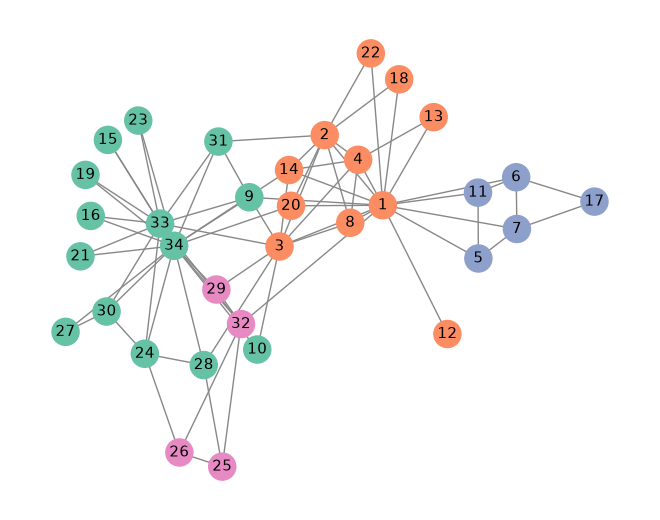

In [19]:
# Put the largest community first
communities = sorted(communities, key=len, reverse=True)

colors = plt.get_cmap("Set2").colors
node_color = {}
for i, community in enumerate(communities):
    for node in community:
        node_color[node] = colors[i]

plt.figure(figsize=(6.4, 5))
nx.draw(
    karate_g,
    pos=nx.spring_layout(karate_g, seed=415),
    with_labels=True,
    node_color=[node_color[v] for v in karate_g],
    node_size=380,
    font_size=11,
    edge_color="#888888",
)
plt.show()

The picture has four colors, one for each community.
The nodes of one community are close together, because they share many edges.

## Communities of the character network

Now find the communities of the character network of book 1.

The Louvain method has random steps, so the code sets a seed.
The result also depends on the version of NetworkX: the sizes in this notebook come from NetworkX 3.7, and an older version can put a few characters in another community.

In [20]:
communities_1 = nx.community.louvain_communities(G_1, seed=415)
communities_1 = sorted(communities_1, key=len, reverse=True)

len(communities_1)

7

The method finds 7 communities.
`sorted` puts the largest community first.

In [21]:
[len(c) for c in communities_1]

[41, 39, 30, 27, 26, 22, 2]

The sizes are `[41, 39, 30, 27, 26, 22, 2]`.
Six communities have 22 to 41 characters, and one has 2.

In [22]:
nx.community.modularity(G_1, communities_1)

0.47996392052255393

The modularity is 0.48 (the call returns 0.47996392052255393).

To see who is in each community, list its four characters with the highest degree.
The sort key puts the highest degree first, and it sorts characters with the same degree by name.

In [23]:
degree = dict(G_1.degree())

for i, community in enumerate(communities_1):
    members = sorted(community, key=lambda v: (-degree[v], v))[:4]
    print(f"Community {i} ({len(community)} characters): {', '.join(members)}")

Community 0 (41 characters): Catelyn-Stark, Robb-Stark, Bran-Stark, Tywin-Lannister
Community 1 (39 characters): Robert-Baratheon, Sansa-Stark, Cersei-Lannister, Joffrey-Baratheon
Community 2 (30 characters): Tyrion-Lannister, Rodrik-Cassel, Lysa-Arryn, Bronn
Community 3 (27 characters): Eddard-Stark, Jory-Cassel, Tomard, Alyn
Community 4 (26 characters): Jon-Snow, Jeor-Mormont, Samwell-Tarly, Alliser-Thorne
Community 5 (22 characters): Daenerys-Targaryen, Drogo, Jorah-Mormont, Irri
Community 6 (2 characters): Mace-Tyrell, Paxter-Redwyne


The first three lines of the output:

```text
Community 0 (41 characters): Catelyn-Stark, Robb-Stark, Bran-Stark, Tywin-Lannister
Community 1 (39 characters): Robert-Baratheon, Sansa-Stark, Cersei-Lannister, Joffrey-Baratheon
Community 2 (30 characters): Tyrion-Lannister, Rodrik-Cassel, Lysa-Arryn, Bronn
```

The last cell draws the network. It has three steps.

1. Give each node the number and the color of its community.
2. Compute the layout. A spring layout pulls two connected nodes together. The code gives an edge inside a community the weight 1 and an edge between two communities the weight 0.08, so the layout keeps each community together.
3. Draw the edges, the nodes, and the labels. The size of a node shows its degree. The label of a community is its character with the highest degree. The community with two characters gets no label.

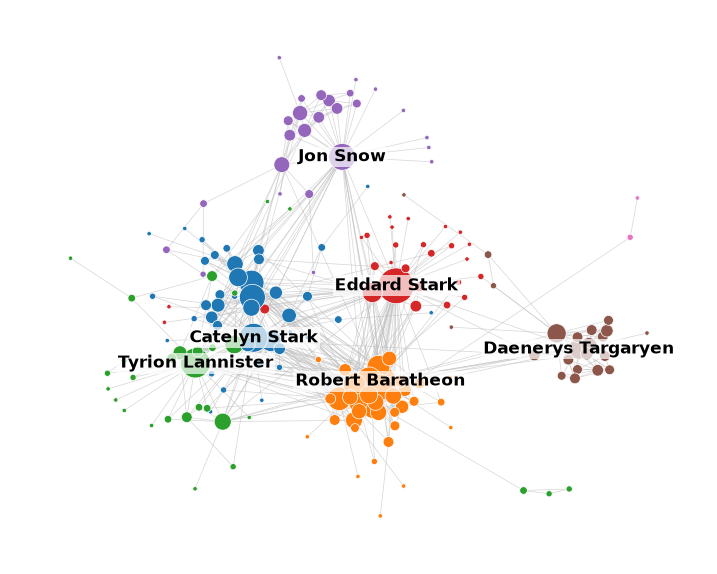

In [24]:
# Step 1: the community and the color of each node
community_of = {}
for i, community in enumerate(communities_1):
    for node in community:
        community_of[node] = i
colors = plt.get_cmap("tab10").colors

# Step 2: edges inside a community pull harder than edges between communities
layout_graph = nx.Graph()
layout_graph.add_nodes_from(G_1)
for u, v in G_1.edges():
    same = community_of[u] == community_of[v]
    layout_graph.add_edge(u, v, weight=1.0 if same else 0.08)
pos = nx.spring_layout(layout_graph, seed=415, k=1.1, iterations=300)

# Step 3: draw the edges, the nodes, and the labels
plt.figure(figsize=(9, 7.2))
nx.draw_networkx_edges(G_1, pos, edge_color="#bbbbbb", width=0.5, alpha=0.6)
nx.draw_networkx_nodes(
    G_1,
    pos,
    node_color=[colors[community_of[v]] for v in G_1],
    node_size=[10 * degree[v] for v in G_1],
    linewidths=0.5,
    edgecolors="white",
)
top = [max(c, key=degree.get) for c in communities_1 if len(c) > 2]
nx.draw_networkx_labels(
    G_1,
    pos,
    labels={v: v.replace("-", " ") for v in top},
    font_size=12,
    font_weight="bold",
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 1.5},
)
plt.axis("off")
plt.show()

Each color is one community.
The six labels are Catelyn Stark, Robert Baratheon, Tyrion Lannister, Eddard Stark, Jon Snow, and Daenerys Targaryen.
The characters of one community are close together in the picture.